<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/Single_CPW_Resonator_with_PHIDL_and_GDSTK_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q uv
!uv pip install --system "phidl==1.7.2" "gdstk==1.0.1" matplotlib numpy "networkx>=3.0"

Using Python 3.13.15 environment at: /usr
Checked 5 packages in 142ms
PHIDL + GDSTK layout generated successfully.

CPW air-gap geometry
  Feedline trace width       : 11.70 µm
  Feedline ground gap        : 8.00 µm per side
  Resonator trace width      : 10.00 µm
  Resonator ground gap       : 8.00 µm per side
  Coupled conductor clearance: 6.00 µm
  Feedline Z0 estimate       : 52.83 ohm
  Resonator Z0 estimate      : 55.30 ohm
  Open-end gap extension     : 8.00 µm

Resonator
  Target frequency           : 6.450 GHz
  Target quarter-wave length : 4651.16 µm
  Filleted centerline length : 4651.16 µm
  Fillet radius              : 70.00 µm
  Selected equal sweeps      : 3
  Equal sweep span           : 1230.48 µm
  Footprint width target     : 966.00 µm
  Footprint width selected   : 966.00 µm
  Preferred meander pitch    : 300.00 µm
  Selected meander pitch     : 240.00 µm
  Feedline-relative angle    : 90.00 deg
  Remote termination         : short

Geometry audit
  Air-cut / metal 

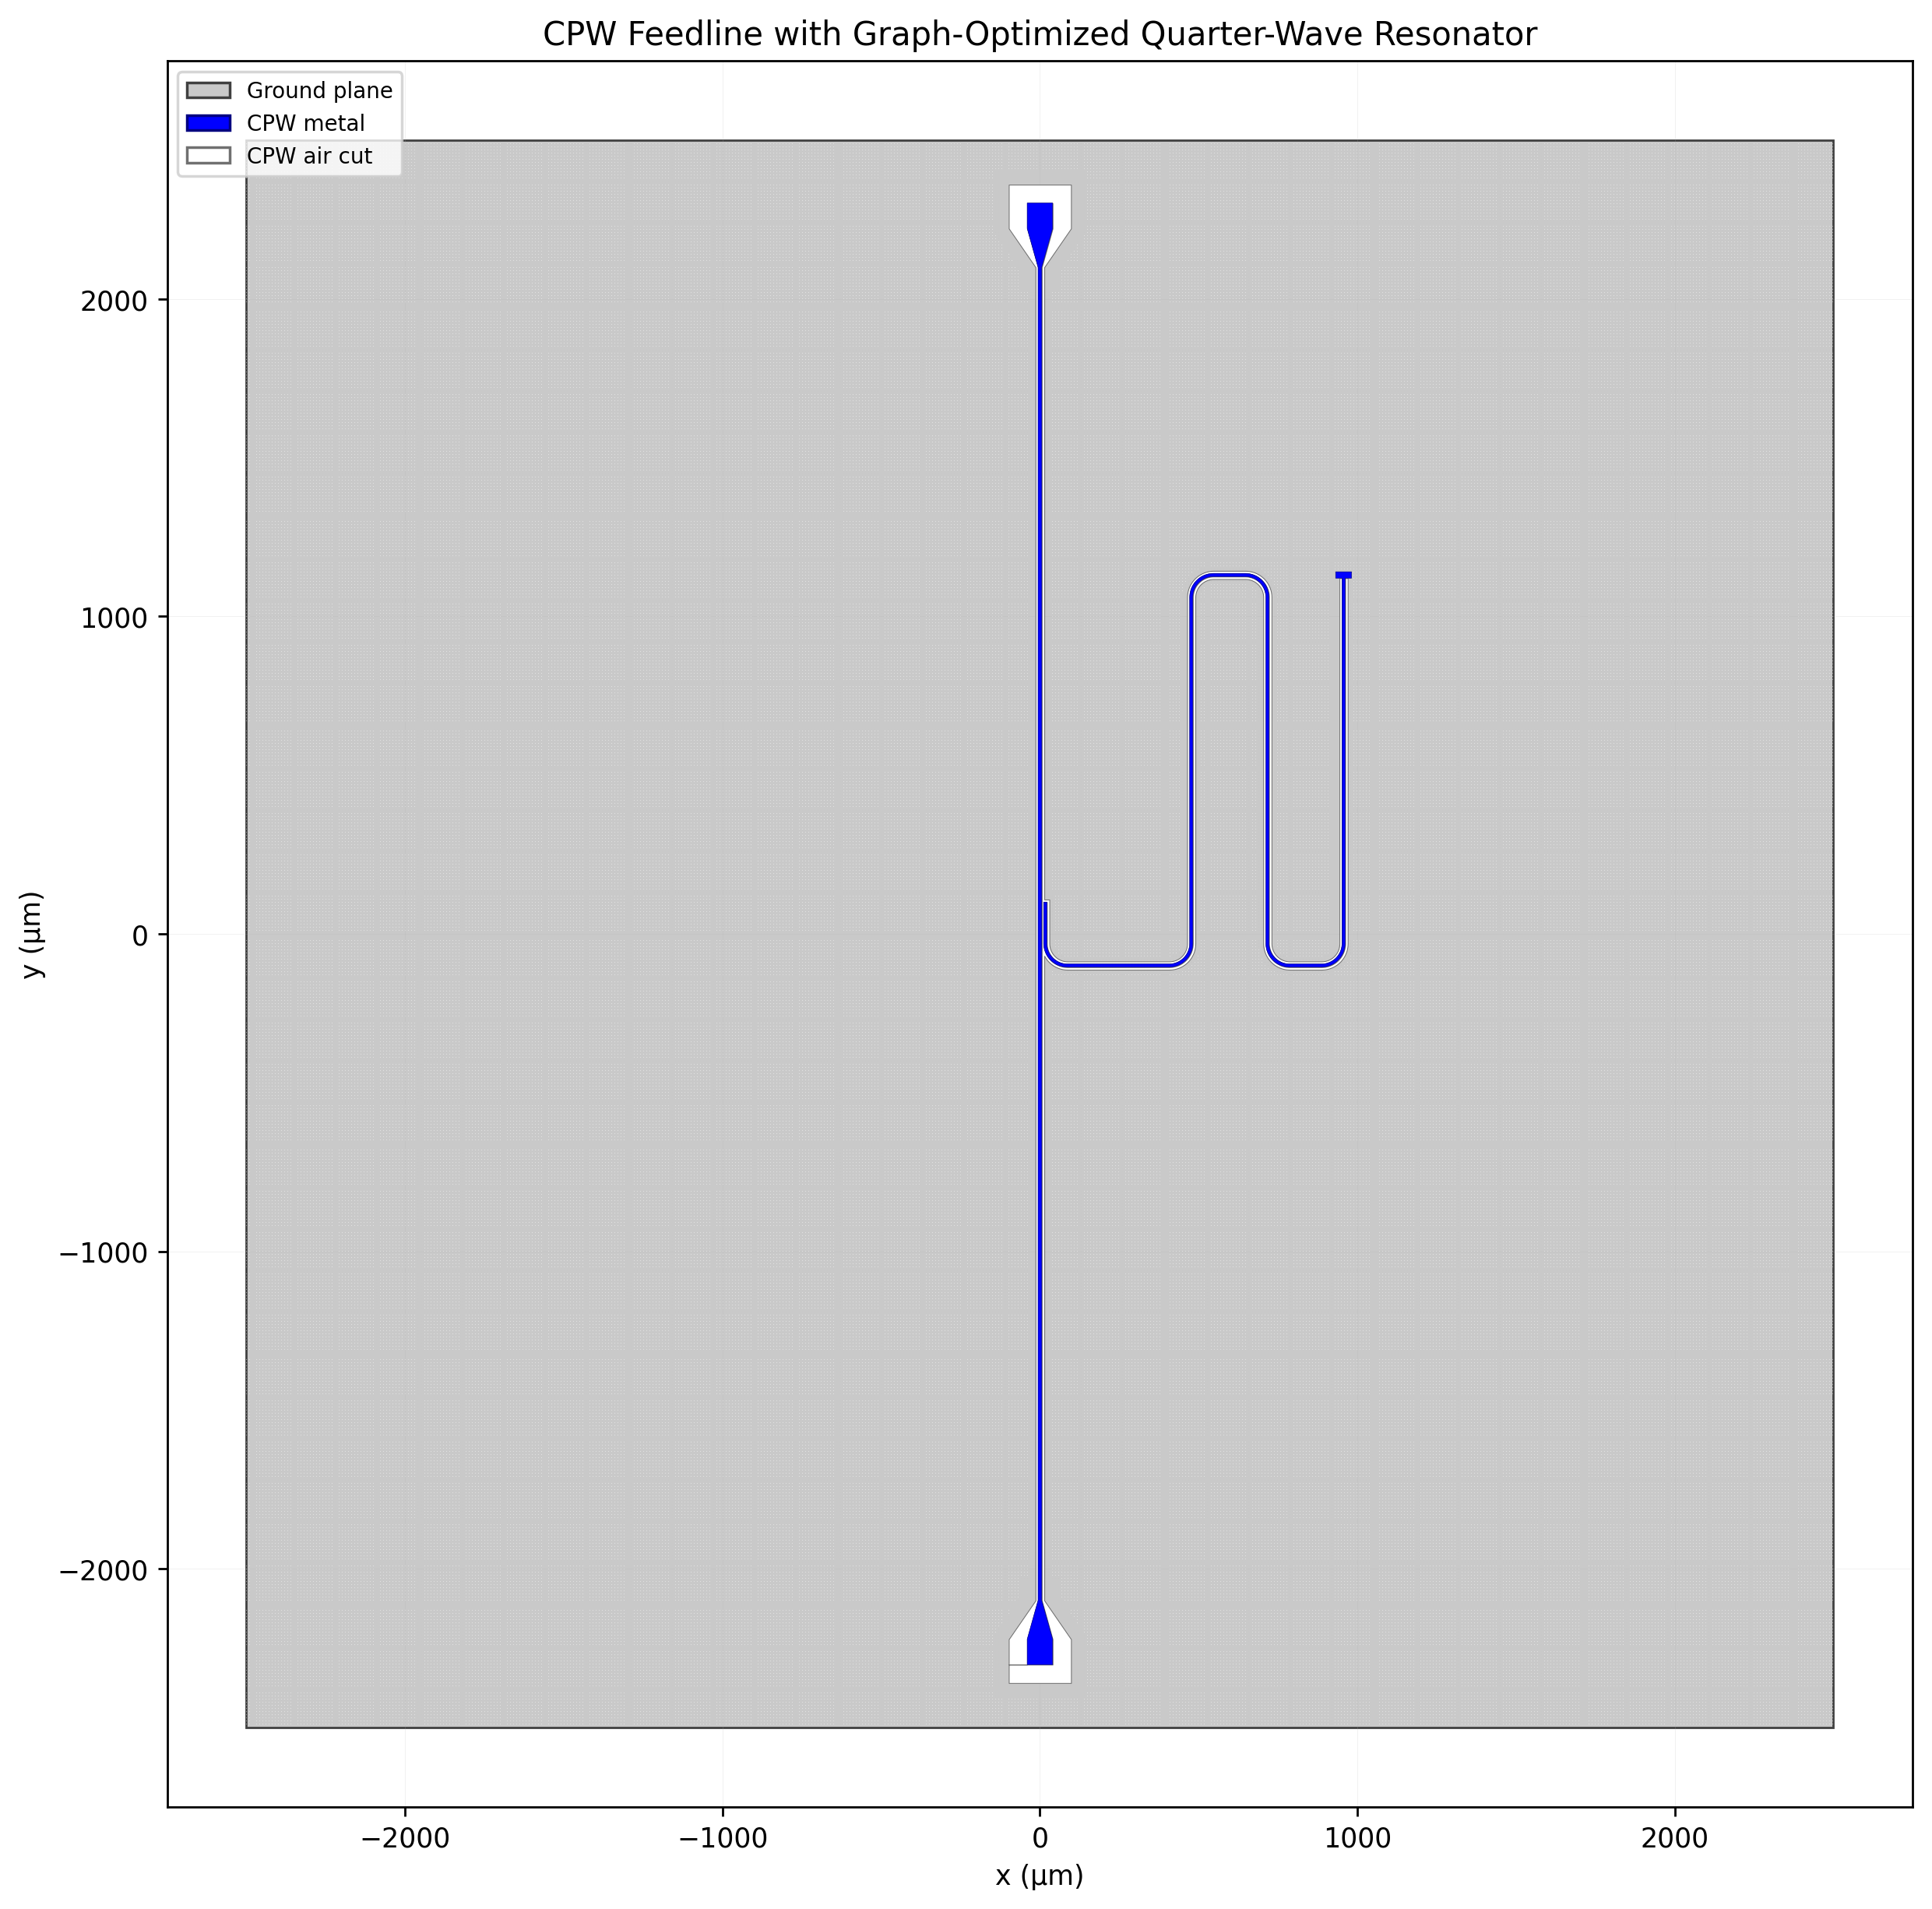

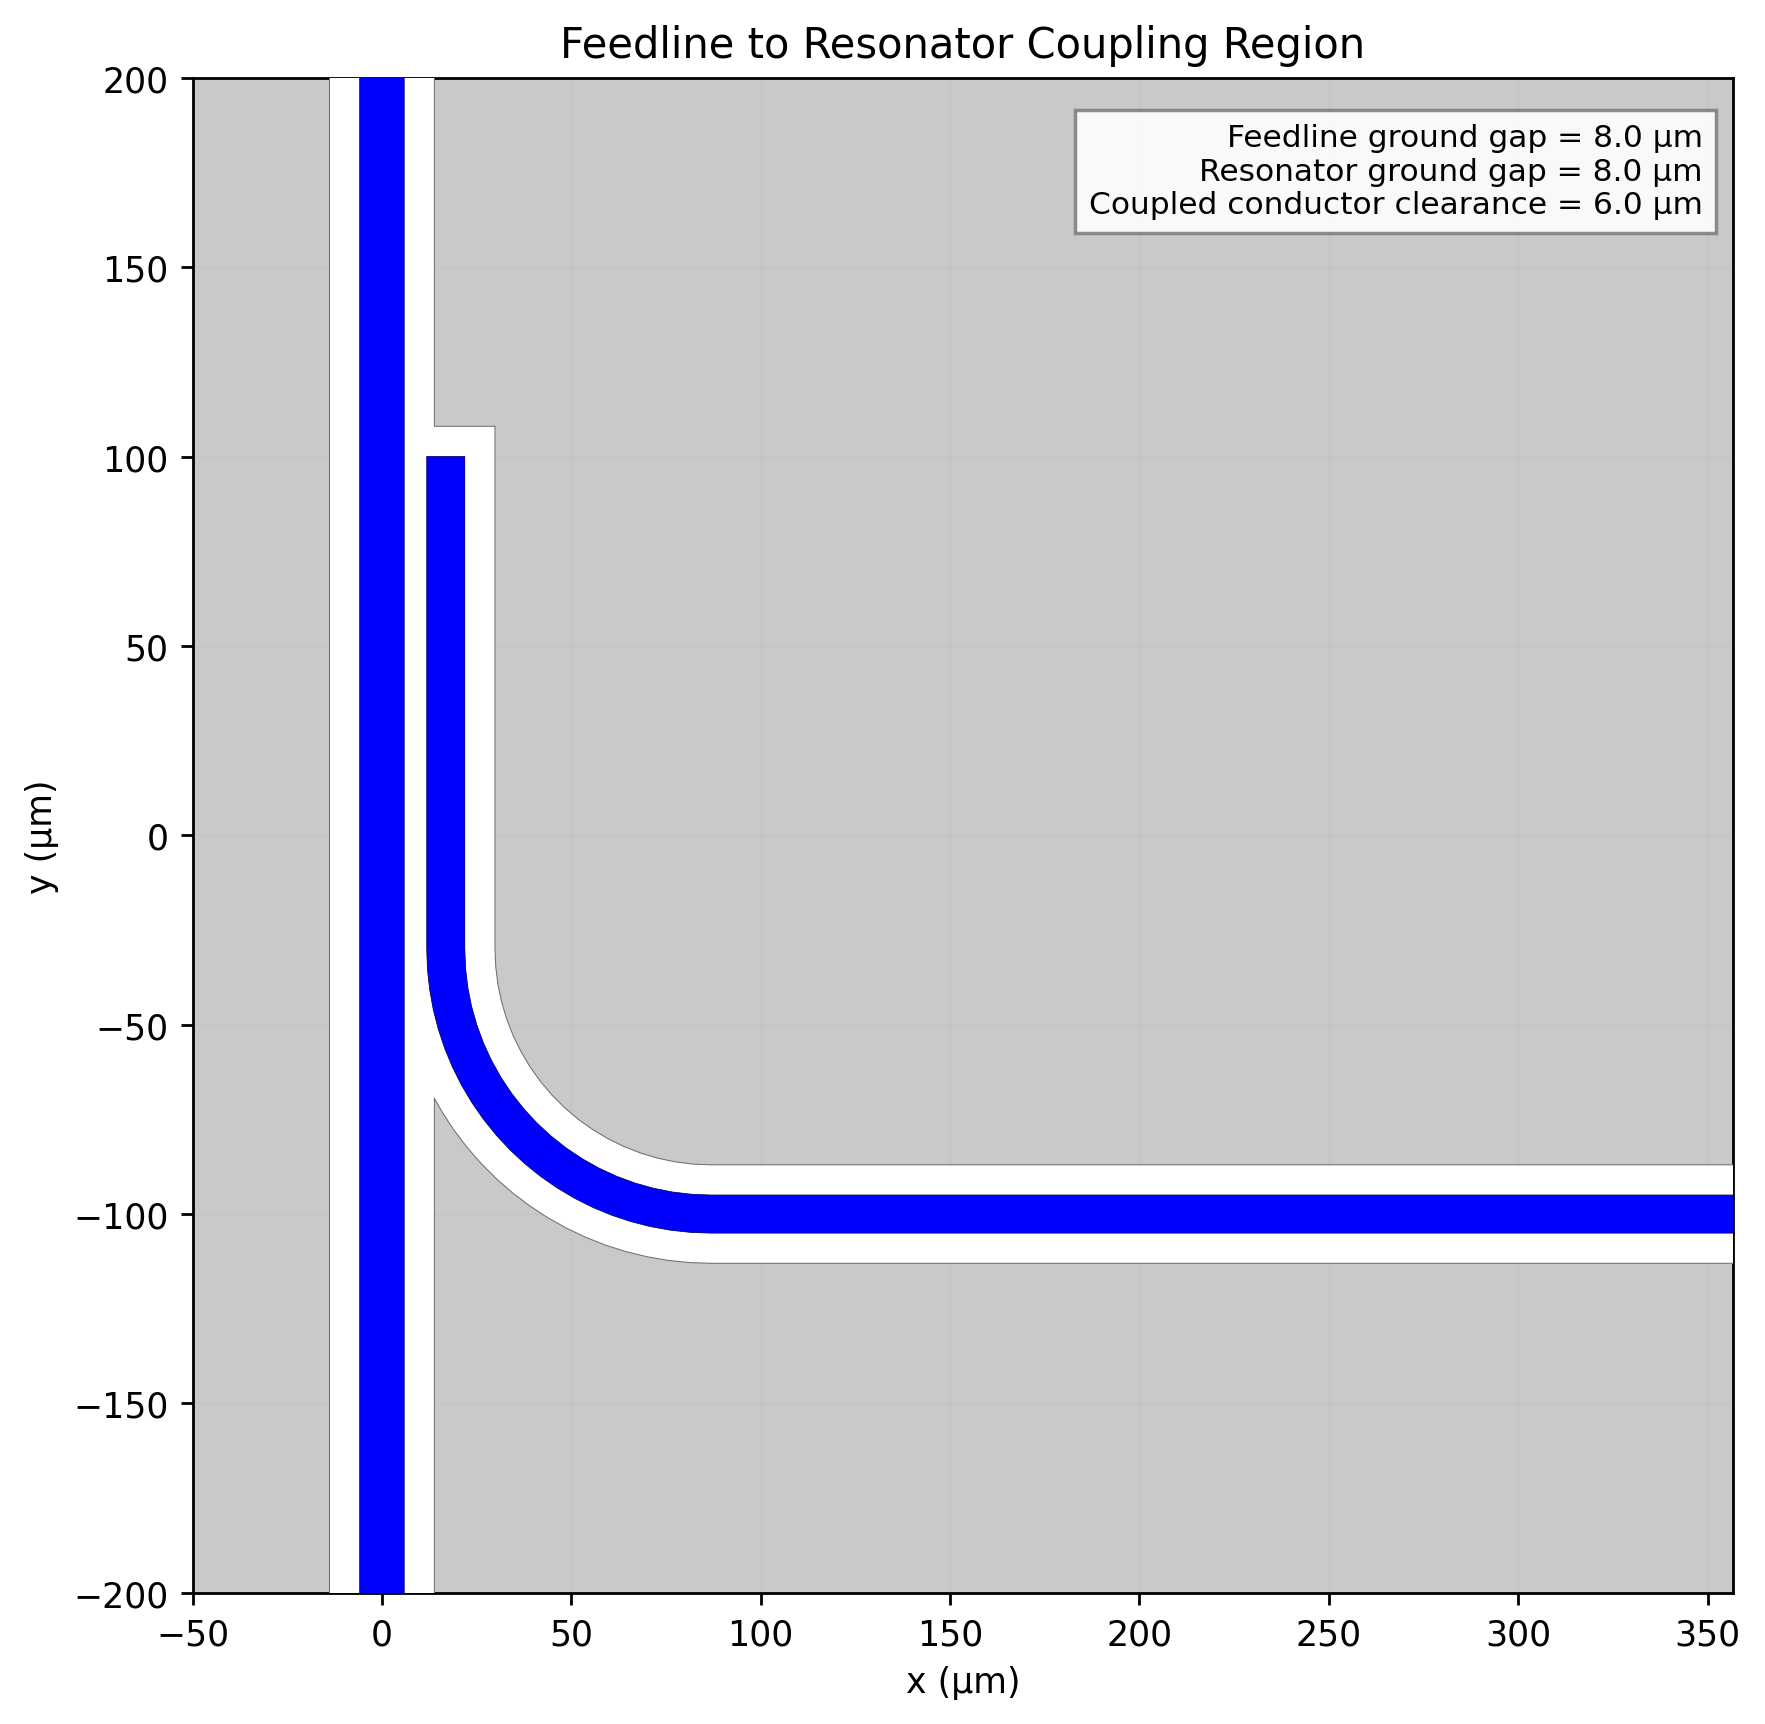

In [15]:
!pip install -q uv
!uv pip install --system "phidl==1.7.2" "gdstk==1.0.1" matplotlib numpy "networkx>=3.0"

"""Build a PHIDL and GDSTK CPW feedline with one meandered resonator.

The layout contains Qiskit Metal LaunchpadWirebond style launchers,
explicit CPW air cuts, a filtered square antidot lattice, an in-memory
Matplotlib preview, and a verified GDSII output.
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Final

import gdstk
import matplotlib as mpl
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.patches import Rectangle
from phidl import Device


# -----------------------------------------------------------------------------
# CONTROL KNOBS
# -----------------------------------------------------------------------------

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/cpw_resonator.gds"
)

WRITE_GDS: Final[bool] = True
VERIFY_GDS_AFTER_WRITE: Final[bool] = True
DOWNLOAD_GDS_AFTER_WRITE: Final[bool] = False

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 10.0
FIGURE_HEIGHT_IN: Final[float] = 10.0
RENDER_COUPLER_ZOOM: Final[bool] = True

CHIP_SIZE_X_UM: Final[float] = 5000.0
CHIP_SIZE_Y_UM: Final[float] = 5000.0

GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9
BOOLEAN_PRECISION_UM: Final[float] = 1.0e-3


# -----------------------------------------------------------------------------
# GDS LAYER MAP
# -----------------------------------------------------------------------------

METAL_LAYER: Final[int] = 3
METAL_DATATYPE: Final[int] = 0

AIR_CUT_LAYER: Final[int] = 3
AIR_CUT_DATATYPE: Final[int] = 1

METAL_SPEC: Final[tuple[int, int]] = (
    METAL_LAYER,
    METAL_DATATYPE,
)

FOOTPRINT_SPEC: Final[tuple[int, int]] = (
    AIR_CUT_LAYER,
    AIR_CUT_DATATYPE,
)


# -----------------------------------------------------------------------------
# FEEDLINE CPW
# -----------------------------------------------------------------------------

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_TRACE_GAP_UM: Final[float] = 8.0


# -----------------------------------------------------------------------------
# QISKIT METAL LAUNCHPADWIREBOND GEOMETRY
# -----------------------------------------------------------------------------

LAUNCHER_CENTER_Y_UM: Final[float] = 2100.0

LAUNCHER_LEAD_LENGTH_UM: Final[float] = 25.0
LAUNCHER_PAD_WIDTH_UM: Final[float] = 80.0
LAUNCHER_PAD_HEIGHT_UM: Final[float] = 80.0
LAUNCHER_PAD_GAP_UM: Final[float] = 58.0
LAUNCHER_TAPER_HEIGHT_UM: Final[float] = 122.0

TOP_LAUNCHER_ORIENTATION_DEG: Final[float] = -90.0
BOTTOM_LAUNCHER_ORIENTATION_DEG: Final[float] = 90.0


# -----------------------------------------------------------------------------
# SINGLE MEANDERING CPW RESONATOR
# -----------------------------------------------------------------------------

RESONATOR_TRACE_WIDTH_UM: Final[float] = 10.0
RESONATOR_TRACE_GAP_UM: Final[float] = 8.0

# The coupler gap controls external coupling and still requires EM tuning.
RESONATOR_COUPLING_SPACE_UM: Final[float] = 6.0
RESONATOR_COUPLING_LENGTH_UM: Final[float] = 200.0
RESONATOR_COUPLER_CENTER_Y_UM: Final[float] = 0.0

# Keep one full bend radius everywhere instead of shrinking the fillet to fit
# a short terminal segment.
RESONATOR_FILLET_UM: Final[float] = 70.0
RESONATOR_LEAD_START_UM: Final[float] = 220.0

RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM: Final[float] = 966.0
"""Set the outer width allocated to the meandering resonator.

Width is measured along the meander progression axis from the downstream
coupler endpoint across the escape lead and folded body. The CPW trace and
both ground gaps are included in the outer footprint width.

At the default 90-degree feedline-relative angle, this value corresponds to
the horizontal distance occupied by the resonator away from the feedline.
"""

RESONATOR_MEANDER_PITCH_UM: Final[float] = 300.0
"""Set the preferred centerline-to-centerline meander pitch.

The graph planner treats this value as a design target. It calculates the
actual pitch required by the requested footprint width for each legal sweep
count, then favors the candidate whose calculated pitch lies closest to this
value. Electrical length, bend clearance, self-clearance, and chip bounds
retain priority over the pitch preference.
"""

RESONATOR_FEEDLINE_ANGLE_DEG: Final[float] = 90.0
"""Set the meander longitudinal-axis angle relative to the feedline.

Zero degrees places the overall meander progression parallel to the feedline.
Ninety degrees places the overall meander progression perpendicular to the
feedline and is the default configuration.

The feedline-facing coupling section and the escape lead stay fixed. Rotation
starts at the end of the escape lead, which preserves the parallel coupling
gap and prevents a 90-degree setting from folding the lead over the coupler.

Any finite angle is accepted initially. Geometry audits reject orientations
that violate bend, self-clearance, chip-bound, or conductor-overlap rules.
"""

# NetworkX chooses among legal equal-span serpentine topologies. The selected
# route is compact, approximately square, and contains no truncated sweep.
RESONATOR_SWEEP_COUNT_MIN: Final[int] = 2
RESONATOR_SWEEP_COUNT_MAX: Final[int] = 8
RESONATOR_MIN_SWEEP_SPAN_UM: Final[float] = 350.0
RESONATOR_MAX_SWEEP_SPAN_UM: Final[float] = 1500.0
RESONATOR_TARGET_ASPECT_RATIO: Final[float] = 1.0

RESONATOR_AREA_COST_WEIGHT: Final[float] = 0.20
RESONATOR_ASPECT_COST_WEIGHT: Final[float] = 0.10
RESONATOR_PITCH_COST_WEIGHT: Final[float] = 1.00
RESONATOR_BEND_COST_WEIGHT: Final[float] = 0.02

# Microwave spacing budget measured between the outer edges of nonadjacent
# resonator CPW footprints, not only between center conductors.
RESONATOR_MIN_SELF_EDGE_CLEARANCE_UM: Final[float] = 180.0

# Preserve a finite straight tangent between neighboring fillet arcs.
RESONATOR_MIN_TANGENT_BETWEEN_FILLETS_UM: Final[float] = 30.0

TARGET_RESONATOR_FREQUENCY_GHZ: Final[float] = 6.45
CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8

# Quasi-TEM impedance sanity check. The effective permittivity is inferred from
# the same phase velocity used by the first-pass resonator length model.
SPEED_OF_LIGHT_M_PER_S: Final[float] = 299_792_458.0
CPW_TARGET_IMPEDANCE_OHM: Final[float] = 50.0
CPW_IMPEDANCE_TOLERANCE_OHM: Final[float] = 8.0

# A side-coupled quarter-wave hanger has an open end at the feedline coupler
# and a short-to-ground termination at the remote end.
RESONATOR_REMOTE_TERMINATION: Final[str] = "short"

# The open termination gets a complete air cap equal to the local CPW gap.
OPEN_END_GAP_EXTENSION_UM: Final[float] = RESONATOR_TRACE_GAP_UM

# The shorting bar bridges the center strip across both CPW slots and overlaps
# the surrounding ground region in the layout view.
SHORT_TO_GROUND_BAR_DEPTH_UM: Final[float] = 20.0
SHORT_TO_GROUND_OVERLAP_UM: Final[float] = 12.0


# -----------------------------------------------------------------------------
# ANTIDOT LATTICE
# -----------------------------------------------------------------------------

ENABLE_ANTIDOTS: Final[bool] = True

ANTIDOT_PITCH_UM: Final[float] = 10.0
ANTIDOT_SIZE_UM: Final[float] = 2.0

ANTIDOT_OFFSET_X_UM: Final[float] = 9.0
ANTIDOT_OFFSET_Y_UM: Final[float] = 0.0
ANTIDOT_EXTENSION_Y_UM: Final[float] = 60.0

ANTIDOT_KEEPOUT_UM: Final[float] = 15.0
LAUNCHPAD_KEEPOUT_UM: Final[float] = 45.0

CLIP_ANTIDOTS_TO_CHIP: Final[bool] = True


# -----------------------------------------------------------------------------
# LIGHTWEIGHT DESIGN CHECKS
# -----------------------------------------------------------------------------

MIN_CPW_GAP_UM: Final[float] = 3.0
MIN_METAL_SPACING_UM: Final[float] = 2.0

# Geometry-level microwave checks. Foundry values can replace these controls.
CHIP_EDGE_KEEPOUT_UM: Final[float] = 100.0
MAX_METAL_OVERLAP_AREA_UM2: Final[float] = 1.0
GROUND_COMPONENT_AREA_TOLERANCE_UM2: Final[float] = 1.0

MAX_SAME_LAYER_GROUND_COMPONENTS: Final[int] = 2
"""Set the allowed count of disconnected same-layer ground regions.

A single-layer through CPW can divide the visible top ground into two large
banks. Package ground bonds, airbridges, or crossovers can tie those banks
together electrically. More than two same-layer components usually indicate
an unintended floating ground island in this layout.
"""


# -----------------------------------------------------------------------------
# RENDERING CONTROLS
# -----------------------------------------------------------------------------

GROUND_FACE: Final[str] = "#C9C9C9"
CHIP_EDGE: Final[str] = "#404040"

METAL_FACE: Final[str] = "#0000FF"
METAL_EDGE: Final[str] = "#000080"

AIR_FACE: Final[str] = "#FFFFFF"
AIR_EDGE: Final[str] = "#707070"

ANTIDOT_FACE: Final[str] = "#FFFFFF"
ANTIDOT_ALPHA: Final[float] = 0.45

mpl.rcParams["font.sans-serif"] = [
    "Tahoma",
    "DejaVu Sans",
]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = MPL_DPI


# -----------------------------------------------------------------------------
# DATA STRUCTURES
# -----------------------------------------------------------------------------


@dataclass
class LayoutResult:
    """Store generated PHIDL and GDSTK layout information."""

    phidl_device: Device
    library: gdstk.Library
    top_cell: gdstk.Cell

    conductor_polygons: list[gdstk.Polygon]
    air_cut_polygons: list[gdstk.Polygon]

    ordinary_footprints: list[gdstk.Polygon]
    launcher_footprints: list[gdstk.Polygon]

    antidot_points: np.ndarray
    antidot_references: list[gdstk.Reference]

    resonator_points: np.ndarray

    resonator_target_length_um: float
    resonator_rounded_length_um: float
    resonator_fillet_um: float
    resonator_sweep_count: int
    resonator_sweep_span_um: float
    resonator_meander_pitch_um: float
    resonator_footprint_width_um: float
    resonator_min_self_clearance_um: float
    resonator_min_segment_um: float

    ground_component_count: int
    feedline_resonator_overlap_um2: float

    candidate_antidot_count: int

    gds_path: Path
    gds_size_bytes: int


# -----------------------------------------------------------------------------
# BASIC GEOMETRY HELPERS
# -----------------------------------------------------------------------------


def add_rectangle(
    device: Device,
    x0: float,
    y0: float,
    x1: float,
    y1: float,
    layer: tuple[int, int],
) -> None:
    """Add an axis-aligned rectangular polygon to a PHIDL device."""

    x_min = min(x0, x1)
    x_max = max(x0, x1)
    y_min = min(y0, y1)
    y_max = max(y0, y1)

    device.add_polygon(
        [
            (x_min, y_min),
            (x_max, y_min),
            (x_max, y_max),
            (x_min, y_max),
        ],
        layer=layer,
    )


def union_polygons(
    polygons: list[gdstk.Polygon],
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Return the Boolean union of a polygon collection."""

    if len(polygons) == 0:
        return []

    return gdstk.boolean(
        polygons,
        [],
        "or",
        precision=BOOLEAN_PRECISION_UM,
        layer=layer,
        datatype=datatype,
    )


def phidl_polygons_to_gdstk(
    device: Device,
    spec: tuple[int, int],
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert one PHIDL layer specification to GDSTK polygons."""

    polygons_by_spec = device.get_polygons(
        by_spec=True
    )

    polygon_arrays = polygons_by_spec.get(
        spec,
        [],
    )

    return [
        gdstk.Polygon(
            np.asarray(
                points,
                dtype=np.float64,
            ),
            layer=layer,
            datatype=datatype,
        )
        for points in polygon_arrays
    ]


# -----------------------------------------------------------------------------
# QISKIT METAL STYLE LAUNCHER
# -----------------------------------------------------------------------------


def create_launchpad_wirebond(
    name: str,
    pos_x_um: float,
    pos_y_um: float,
    orientation_deg: float,
) -> Device:
    """Create the supplied Qiskit Metal LaunchpadWirebond geometry."""

    device = Device(name)

    trace_half = (
        FEEDLINE_TRACE_WIDTH_UM
        / 2.0
    )

    pad_half = (
        LAUNCHER_PAD_WIDTH_UM
        / 2.0
    )

    lead_length = (
        LAUNCHER_LEAD_LENGTH_UM
    )

    taper_height = (
        LAUNCHER_TAPER_HEIGHT_UM
    )

    pad_height = (
        LAUNCHER_PAD_HEIGHT_UM
    )

    pad_gap = (
        LAUNCHER_PAD_GAP_UM
    )

    trace_gap = (
        FEEDLINE_TRACE_GAP_UM
    )

    # - Positive launch metal

    launch_pad = [
        (
            0.0,
            trace_half,
        ),
        (
            -taper_height,
            pad_half,
        ),
        (
            -(pad_height + taper_height),
            pad_half,
        ),
        (
            -(pad_height + taper_height),
            -pad_half,
        ),
        (
            -taper_height,
            -pad_half,
        ),
        (
            0.0,
            -trace_half,
        ),
        (
            lead_length,
            -trace_half,
        ),
        (
            lead_length,
            trace_half,
        ),
        (
            0.0,
            trace_half,
        ),
    ]

    # - Qiskit Metal ground pocket

    pocket = [
        (
            0.0,
            trace_half + trace_gap,
        ),
        (
            -taper_height,
            pad_half + pad_gap,
        ),
        (
            -(
                pad_height
                + taper_height
                + pad_gap
            ),
            pad_half + pad_gap,
        ),
        (
            -(
                pad_height
                + taper_height
                + pad_gap
            ),
            -(pad_half + pad_gap),
        ),
        (
            -taper_height,
            -(pad_half + pad_gap),
        ),
        (
            0.0,
            -(trace_half + trace_gap),
        ),
        (
            lead_length,
            -(trace_half + trace_gap),
        ),
        (
            lead_length,
            trace_half + trace_gap,
        ),
        (
            0.0,
            trace_half + trace_gap,
        ),
    ]

    device.add_polygon(
        launch_pad,
        layer=METAL_SPEC,
    )

    device.add_polygon(
        pocket,
        layer=FOOTPRINT_SPEC,
    )

    device.add_port(
        name="tie",
        midpoint=(
            lead_length,
            0.0,
        ),
        width=FEEDLINE_TRACE_WIDTH_UM,
        orientation=0.0,
    )

    device.rotate(
        angle=orientation_deg,
        center=(
            0.0,
            0.0,
        ),
    )

    device.move(
        origin=(
            0.0,
            0.0,
        ),
        destination=(
            pos_x_um,
            pos_y_um,
        ),
    )

    return device


# -----------------------------------------------------------------------------
# FEEDLINE
# -----------------------------------------------------------------------------


def create_feedline(
    top_launcher: Device,
    bottom_launcher: Device,
) -> Device:
    """Create the straight vertical CPW between both launcher tie pins."""

    device = Device(
        "feedline"
    )

    top_pin = np.asarray(
        top_launcher.ports[
            "tie"
        ].midpoint,
        dtype=np.float64,
    )

    bottom_pin = np.asarray(
        bottom_launcher.ports[
            "tie"
        ].midpoint,
        dtype=np.float64,
    )

    center_x = float(
        0.5
        * (
            top_pin[0]
            + bottom_pin[0]
        )
    )

    y_min = float(
        min(
            top_pin[1],
            bottom_pin[1],
        )
    )

    y_max = float(
        max(
            top_pin[1],
            bottom_pin[1],
        )
    )

    conductor_half = (
        FEEDLINE_TRACE_WIDTH_UM
        / 2.0
    )

    footprint_half = (
        conductor_half
        + FEEDLINE_TRACE_GAP_UM
    )

    add_rectangle(
        device=device,
        x0=center_x - conductor_half,
        y0=y_min,
        x1=center_x + conductor_half,
        y1=y_max,
        layer=METAL_SPEC,
    )

    add_rectangle(
        device=device,
        x0=center_x - footprint_half,
        y0=y_min,
        x1=center_x + footprint_half,
        y1=y_max,
        layer=FOOTPRINT_SPEC,
    )

    return device


# -----------------------------------------------------------------------------
# RESONATOR LENGTH AND GRAPH-ASSISTED MEANDER PLANNER
# -----------------------------------------------------------------------------



def complete_elliptic_k_agm(
    modulus: float,
) -> float:
    """Calculate complete elliptic K with the arithmetic-geometric mean."""

    if (
        modulus <= 0.0
        or modulus >= 1.0
    ):
        raise ValueError(
            "Elliptic modulus must lie between zero and one."
        )

    arithmetic = 1.0
    geometric = float(
        np.sqrt(
            1.0
            - modulus**2
        )
    )

    for _ in range(
        80
    ):
        next_arithmetic = (
            0.5
            * (
                arithmetic
                + geometric
            )
        )

        next_geometric = float(
            np.sqrt(
                arithmetic
                * geometric
            )
        )

        if abs(
            next_arithmetic
            - next_geometric
        ) <= 1.0e-15:
            arithmetic = next_arithmetic
            break

        arithmetic = next_arithmetic
        geometric = next_geometric

    return float(
        np.pi
        / (
            2.0
            * arithmetic
        )
    )


def approximate_cpw_impedance_ohm(
    trace_width_um: float,
    trace_gap_um: float,
) -> float:
    """Estimate CPW impedance from quasi-TEM conformal-mapping relations."""

    effective_permittivity = (
        SPEED_OF_LIGHT_M_PER_S
        / CPW_PHASE_VELOCITY_M_PER_S
    ) ** 2

    modulus = (
        trace_width_um
        / (
            trace_width_um
            + 2.0
            * trace_gap_um
        )
    )

    complementary_modulus = float(
        np.sqrt(
            1.0
            - modulus**2
        )
    )

    k_value = (
        complete_elliptic_k_agm(
            modulus
        )
    )

    k_complementary = (
        complete_elliptic_k_agm(
            complementary_modulus
        )
    )

    return float(
        30.0
        * np.pi
        / np.sqrt(
            effective_permittivity
        )
        * k_complementary
        / k_value
    )


def resonator_target_length_um(
    frequency_ghz: float,
) -> float:
    """Calculate the first-pass resonator centerline length."""

    frequency_hz = frequency_ghz * 1.0e9

    if RESONATOR_REMOTE_TERMINATION == "short":
        wavelength_fraction = 0.25
    elif RESONATOR_REMOTE_TERMINATION == "open":
        wavelength_fraction = 0.50
    else:
        raise ValueError(
            "RESONATOR_REMOTE_TERMINATION must be 'short' or 'open'."
        )

    return (
        wavelength_fraction
        * CPW_PHASE_VELOCITY_M_PER_S
        / frequency_hz
        * 1.0e6
    )


def polyline_length_um(
    points: np.ndarray,
) -> float:
    """Calculate total piecewise-linear centerline length."""

    segment_vectors = np.diff(
        points,
        axis=0,
    )

    segment_lengths = np.linalg.norm(
        segment_vectors,
        axis=1,
    )

    return float(
        np.sum(
            segment_lengths
        )
    )


def rounded_centerline_length_um(
    points: np.ndarray,
    radius_um: float,
) -> float:
    """Estimate centerline length after circular corner replacement."""

    total_length = polyline_length_um(
        points
    )

    if radius_um <= 0.0:
        return total_length

    length_reduction = 0.0

    for index in range(
        1,
        points.shape[0] - 1,
    ):
        incoming = (
            points[index]
            - points[index - 1]
        )

        outgoing = (
            points[index + 1]
            - points[index]
        )

        incoming_length = float(
            np.linalg.norm(
                incoming
            )
        )

        outgoing_length = float(
            np.linalg.norm(
                outgoing
            )
        )

        if (
            incoming_length <= 1.0e-12
            or outgoing_length <= 1.0e-12
        ):
            continue

        incoming_unit = (
            incoming
            / incoming_length
        )

        outgoing_unit = (
            outgoing
            / outgoing_length
        )

        cosine_angle = float(
            np.clip(
                np.dot(
                    incoming_unit,
                    outgoing_unit,
                ),
                -1.0,
                1.0,
            )
        )

        angle_rad = float(
            np.arccos(
                cosine_angle
            )
        )

        if (
            angle_rad <= 1.0e-12
            or abs(
                np.pi
                - angle_rad
            )
            <= 1.0e-12
        ):
            continue

        trim_um = (
            radius_um
            * np.tan(
                0.5
                * angle_rad
            )
        )

        arc_length_um = (
            radius_um
            * angle_rad
        )

        length_reduction += (
            2.0
            * trim_um
            - arc_length_um
        )

    return (
        total_length
        - length_reduction
    )


def resonator_coupling_x_um() -> float:
    """Return resonator center x for the requested conductor clearance."""

    feedline_edge = (
        FEEDLINE_TRACE_WIDTH_UM
        / 2.0
    )

    resonator_half = (
        RESONATOR_TRACE_WIDTH_UM
        / 2.0
    )

    return (
        feedline_edge
        + RESONATOR_COUPLING_SPACE_UM
        + resonator_half
    )


def rotate_points_about_anchor(
    points: np.ndarray,
    anchor: np.ndarray,
    angle_deg: float,
) -> np.ndarray:
    """Rotate planar points counterclockwise about one anchor."""

    if abs(angle_deg) <= 1.0e-12:
        return points.copy()

    angle_rad = np.deg2rad(
        angle_deg
    )

    cosine = float(
        np.cos(
            angle_rad
        )
    )

    sine = float(
        np.sin(
            angle_rad
        )
    )

    rotation = np.asarray(
        [
            [
                cosine,
                -sine,
            ],
            [
                sine,
                cosine,
            ],
        ],
        dtype=np.float64,
    )

    shifted = (
        points
        - anchor
    )

    return (
        shifted
        @ rotation.T
        + anchor
    )


def resonator_outer_width_um() -> float:
    """Return the complete CPW outer width of the resonator."""

    return (
        RESONATOR_TRACE_WIDTH_UM
        + 2.0
        * RESONATOR_TRACE_GAP_UM
    )


def meander_progression_unit_vector() -> np.ndarray:
    """Return the unit vector along the folded-body progression direction."""

    base_direction = np.asarray(
        [
            0.0,
            -1.0,
        ],
        dtype=np.float64,
    )

    rotated = rotate_points_about_anchor(
        points=base_direction[
            np.newaxis,
            :
        ],
        anchor=np.zeros(
            2,
            dtype=np.float64,
        ),
        angle_deg=RESONATOR_FEEDLINE_ANGLE_DEG,
    )[0]

    return (
        rotated
        / np.linalg.norm(
            rotated
        )
    )


def meander_footprint_width_um(
    points: np.ndarray,
) -> float:
    """Measure outer resonator width along the meander progression axis."""

    if points.shape[0] < 2:
        return 0.0

    progression = (
        meander_progression_unit_vector()
    )

    projections = (
        points[
            1:
        ]
        @ progression
    )

    centerline_width_um = float(
        np.ptp(
            projections
        )
    )

    return (
        centerline_width_um
        + resonator_outer_width_um()
    )


def minimum_legal_meander_pitch_um() -> float:
    """Return the minimum centerline pitch allowed by spacing and fillets."""

    spacing_minimum_um = (
        resonator_outer_width_um()
        + RESONATOR_MIN_SELF_EDGE_CLEARANCE_UM
    )

    fillet_minimum_um = (
        2.0
        * RESONATOR_FILLET_UM
        + RESONATOR_MIN_TANGENT_BETWEEN_FILLETS_UM
    )

    return float(
        max(
            spacing_minimum_um,
            fillet_minimum_um,
        )
    )


def build_balanced_meander_centerline(
    sweep_count: int,
    sweep_span_um: float,
    meander_pitch_um: float,
) -> np.ndarray:
    """Create the feedline-coupled, angle-controlled serpentine centerline.

    The coupler and escape lead are generated first. The remaining serpentine
    is rotated about the escape-lead endpoint by the feedline-relative angle.
    This gives 0 degrees for a parallel meander and 90 degrees for a
    perpendicular meander without changing the coupler gap.
    """

    coupling_x = resonator_coupling_x_um()

    coupling_half_length = (
        RESONATOR_COUPLING_LENGTH_UM
        / 2.0
    )

    y_top = (
        RESONATOR_COUPLER_CENTER_Y_UM
        + coupling_half_length
    )

    y_bottom = (
        RESONATOR_COUPLER_CENTER_Y_UM
        - coupling_half_length
    )

    current_x = (
        coupling_x
        + RESONATOR_LEAD_START_UM
    )

    current_y = y_bottom

    points: list[list[float]] = [
        [
            coupling_x,
            y_top,
        ],
        [
            coupling_x,
            y_bottom,
        ],
        [
            current_x,
            current_y,
        ],
    ]

    horizontal_direction = 1.0

    for _ in range(
        sweep_count
    ):
        current_y -= (
            meander_pitch_um
        )

        points.append(
            [
                current_x,
                current_y,
            ]
        )

        current_x += (
            horizontal_direction
            * sweep_span_um
        )

        points.append(
            [
                current_x,
                current_y,
            ]
        )

        horizontal_direction *= -1.0

    centerline = np.asarray(
        points,
        dtype=np.float64,
    )

    body_anchor = centerline[
        2
    ].copy()

    centerline[
        3:
    ] = rotate_points_about_anchor(
        points=centerline[
            3:
        ],
        anchor=body_anchor,
        angle_deg=RESONATOR_FEEDLINE_ANGLE_DEG,
    )

    return centerline


def segment_lengths_um(
    points: np.ndarray,
) -> np.ndarray:
    """Return all centerline segment lengths."""

    return np.linalg.norm(
        np.diff(
            points,
            axis=0,
        ),
        axis=1,
    )


def corner_trim_um(
    incoming: np.ndarray,
    outgoing: np.ndarray,
    radius_um: float,
) -> float:
    """Return tangent trim required by one circular centerline fillet."""

    incoming_length = float(
        np.linalg.norm(
            incoming
        )
    )

    outgoing_length = float(
        np.linalg.norm(
            outgoing
        )
    )

    if (
        incoming_length <= 1.0e-12
        or outgoing_length <= 1.0e-12
    ):
        return float(
            "inf"
        )

    incoming_unit = (
        incoming
        / incoming_length
    )

    outgoing_unit = (
        outgoing
        / outgoing_length
    )

    cosine_angle = float(
        np.clip(
            np.dot(
                incoming_unit,
                outgoing_unit,
            ),
            -1.0,
            1.0,
        )
    )

    angle_rad = float(
        np.arccos(
            cosine_angle
        )
    )

    if angle_rad <= 1.0e-12:
        return 0.0

    if (
        np.pi
        - angle_rad
        <= 1.0e-6
    ):
        return float(
            "inf"
        )

    return float(
        radius_um
        * np.tan(
            0.5
            * angle_rad
        )
    )


def fillet_fit_margin_um(
    points: np.ndarray,
    radius_um: float,
) -> float:
    """Return the minimum tangent-length margin around all route fillets."""

    lengths = segment_lengths_um(
        points
    )

    segment_trim_um = np.zeros(
        lengths.shape,
        dtype=np.float64,
    )

    for corner_index in range(
        1,
        points.shape[0] - 1,
    ):
        trim_um = (
            corner_trim_um(
                incoming=(
                    points[corner_index]
                    - points[corner_index - 1]
                ),
                outgoing=(
                    points[corner_index + 1]
                    - points[corner_index]
                ),
                radius_um=radius_um,
            )
        )

        if bool(
            np.isfinite(
                trim_um
            )
        ) is False:
            return float(
                "-inf"
            )

        segment_trim_um[
            corner_index - 1
        ] += trim_um

        segment_trim_um[
            corner_index
        ] += trim_um

    margins = (
        lengths
        - segment_trim_um
        - RESONATOR_MIN_TANGENT_BETWEEN_FILLETS_UM
    )

    return float(
        np.min(
            margins
        )
    )


def point_to_segment_distance_um(
    point: np.ndarray,
    start: np.ndarray,
    end: np.ndarray,
) -> float:
    """Return Euclidean distance from one point to one line segment."""

    segment = end - start
    denominator = float(
        np.dot(
            segment,
            segment,
        )
    )

    if denominator <= 1.0e-24:
        return float(
            np.linalg.norm(
                point
                - start
            )
        )

    projection = float(
        np.dot(
            point - start,
            segment,
        )
        / denominator
    )

    projection = float(
        np.clip(
            projection,
            0.0,
            1.0,
        )
    )

    nearest = (
        start
        + projection
        * segment
    )

    return float(
        np.linalg.norm(
            point
            - nearest
        )
    )


def cross_product_2d(
    first: np.ndarray,
    second: np.ndarray,
) -> float:
    """Return the scalar two-dimensional cross product."""

    return float(
        first[0]
        * second[1]
        - first[1]
        * second[0]
    )


def segments_intersect(
    first_start: np.ndarray,
    first_end: np.ndarray,
    second_start: np.ndarray,
    second_end: np.ndarray,
) -> bool:
    """Return whether two closed planar line segments intersect."""

    first_vector = (
        first_end
        - first_start
    )

    second_vector = (
        second_end
        - second_start
    )

    separation = (
        second_start
        - first_start
    )

    denominator = (
        cross_product_2d(
            first_vector,
            second_vector,
        )
    )

    numerator_first = (
        cross_product_2d(
            separation,
            second_vector,
        )
    )

    numerator_second = (
        cross_product_2d(
            separation,
            first_vector,
        )
    )

    tolerance = 1.0e-12

    if abs(
        denominator
    ) > tolerance:
        first_parameter = (
            numerator_first
            / denominator
        )

        second_parameter = (
            numerator_second
            / denominator
        )

        return (
            -tolerance
            <= first_parameter
            <= 1.0 + tolerance
            and -tolerance
            <= second_parameter
            <= 1.0 + tolerance
        )

    if abs(
        cross_product_2d(
            separation,
            first_vector,
        )
    ) > tolerance:
        return False

    dominant_axis = int(
        np.argmax(
            np.abs(
                first_vector
            )
        )
    )

    first_min = min(
        first_start[dominant_axis],
        first_end[dominant_axis],
    )

    first_max = max(
        first_start[dominant_axis],
        first_end[dominant_axis],
    )

    second_min = min(
        second_start[dominant_axis],
        second_end[dominant_axis],
    )

    second_max = max(
        second_start[dominant_axis],
        second_end[dominant_axis],
    )

    return (
        max(
            first_min,
            second_min,
        )
        <= min(
            first_max,
            second_max,
        )
        + tolerance
    )


def segment_distance_um(
    first_start: np.ndarray,
    first_end: np.ndarray,
    second_start: np.ndarray,
    second_end: np.ndarray,
) -> float:
    """Return minimum Euclidean distance between two planar segments."""

    if segments_intersect(
        first_start,
        first_end,
        second_start,
        second_end,
    ):
        return 0.0

    return min(
        point_to_segment_distance_um(
            first_start,
            second_start,
            second_end,
        ),
        point_to_segment_distance_um(
            first_end,
            second_start,
            second_end,
        ),
        point_to_segment_distance_um(
            second_start,
            first_start,
            first_end,
        ),
        point_to_segment_distance_um(
            second_end,
            first_start,
            first_end,
        ),
    )


def resonator_graph_audit(
    points: np.ndarray,
) -> float:
    """Audit path topology and nonadjacent CPW self-clearance with NetworkX."""

    route_graph = nx.path_graph(
        points.shape[0]
    )

    endpoint_count = sum(
        degree == 1
        for _, degree in route_graph.degree()
    )

    if (
        nx.is_tree(
            route_graph
        )
        is False
        or endpoint_count != 2
    ):
        raise RuntimeError(
            "Resonator route topology must be one simple path with two ends."
        )

    outer_width_um = (
        RESONATOR_TRACE_WIDTH_UM
        + 2.0
        * RESONATOR_TRACE_GAP_UM
    )

    segment_count = (
        points.shape[0]
        - 1
    )

    proximity_graph = nx.Graph()
    proximity_graph.add_nodes_from(
        range(
            segment_count
        )
    )

    minimum_clearance_um = float(
        "inf"
    )

    for first_index in range(
        segment_count
    ):
        for second_index in range(
            first_index + 2,
            segment_count,
        ):
            distance_um = (
                segment_distance_um(
                    points[first_index],
                    points[first_index + 1],
                    points[second_index],
                    points[second_index + 1],
                )
            )

            clearance_um = (
                distance_um
                - outer_width_um
            )

            minimum_clearance_um = min(
                minimum_clearance_um,
                clearance_um,
            )

            if (
                clearance_um
                < RESONATOR_MIN_SELF_EDGE_CLEARANCE_UM
            ):
                proximity_graph.add_edge(
                    first_index,
                    second_index,
                    clearance_um=clearance_um,
                )

    if proximity_graph.number_of_edges() > 0:
        violating_edges = sorted(
            (
                first_index,
                second_index,
                data["clearance_um"],
            )
            for (
                first_index,
                second_index,
                data,
            ) in proximity_graph.edges(
                data=True
            )
        )

        first_violation = (
            violating_edges[0]
        )

        raise ValueError(
            "Resonator self-clearance violation between segments "
            f"{first_violation[0]} and {first_violation[1]}: "
            f"{first_violation[2]:.2f} µm."
        )

    return float(
        minimum_clearance_um
    )


def route_fits_chip(
    points: np.ndarray,
) -> bool:
    """Return whether the complete resonator footprint respects chip keepout."""

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    footprint_half_width_um = (
        RESONATOR_TRACE_WIDTH_UM
        / 2.0
        + RESONATOR_TRACE_GAP_UM
    )

    x_min = float(
        np.min(
            points[:, 0]
        )
        - footprint_half_width_um
    )

    x_max = float(
        np.max(
            points[:, 0]
        )
        + footprint_half_width_um
    )

    y_min = float(
        np.min(
            points[:, 1]
        )
        - footprint_half_width_um
    )

    y_max = float(
        np.max(
            points[:, 1]
        )
        + footprint_half_width_um
    )

    return (
        x_min
        >= -chip_half_x
        + CHIP_EDGE_KEEPOUT_UM
        and x_max
        <= chip_half_x
        - CHIP_EDGE_KEEPOUT_UM
        and y_min
        >= -chip_half_y
        + CHIP_EDGE_KEEPOUT_UM
        and y_max
        <= chip_half_y
        - CHIP_EDGE_KEEPOUT_UM
    )


def solve_pitch_for_footprint_um(
    sweep_count: int,
) -> float | None:
    """Calculate pitch required to satisfy the requested footprint width."""

    minimum_pitch_um = (
        minimum_legal_meander_pitch_um()
    )

    lower_um = minimum_pitch_um

    maximum_centerline_width_um = (
        RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM
        - resonator_outer_width_um()
    )

    if maximum_centerline_width_um <= 0.0:
        return None

    upper_um = max(
        lower_um,
        maximum_centerline_width_um
        + RESONATOR_LEAD_START_UM
        + RESONATOR_COUPLING_LENGTH_UM,
    )

    lower_points = (
        build_balanced_meander_centerline(
            sweep_count=sweep_count,
            sweep_span_um=RESONATOR_MIN_SWEEP_SPAN_UM,
            meander_pitch_um=lower_um,
        )
    )

    lower_width_um = (
        meander_footprint_width_um(
            lower_points
        )
    )

    if (
        lower_width_um
        > RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM
        + 1.0e-9
    ):
        return None

    upper_points = (
        build_balanced_meander_centerline(
            sweep_count=sweep_count,
            sweep_span_um=RESONATOR_MIN_SWEEP_SPAN_UM,
            meander_pitch_um=upper_um,
        )
    )

    upper_width_um = (
        meander_footprint_width_um(
            upper_points
        )
    )

    expansion_count = 0

    while (
        upper_width_um
        < RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM
        and expansion_count < 24
    ):
        upper_um *= 2.0

        upper_points = (
            build_balanced_meander_centerline(
                sweep_count=sweep_count,
                sweep_span_um=RESONATOR_MIN_SWEEP_SPAN_UM,
                meander_pitch_um=upper_um,
            )
        )

        upper_width_um = (
            meander_footprint_width_um(
                upper_points
            )
        )

        expansion_count += 1

    if (
        upper_width_um
        < RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM
    ):
        return None

    for _ in range(
        80
    ):
        midpoint_um = (
            0.5
            * (
                lower_um
                + upper_um
            )
        )

        midpoint_points = (
            build_balanced_meander_centerline(
                sweep_count=sweep_count,
                sweep_span_um=RESONATOR_MIN_SWEEP_SPAN_UM,
                meander_pitch_um=midpoint_um,
            )
        )

        midpoint_width_um = (
            meander_footprint_width_um(
                midpoint_points
            )
        )

        width_error_um = (
            midpoint_width_um
            - RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM
        )

        if abs(
            width_error_um
        ) <= 1.0e-6:
            return float(
                midpoint_um
            )

        if width_error_um < 0.0:
            lower_um = midpoint_um
        else:
            upper_um = midpoint_um

    return float(
        0.5
        * (
            lower_um
            + upper_um
        )
    )


def solve_sweep_span_um(
    sweep_count: int,
    target_length_um: float,
    meander_pitch_um: float,
) -> float | None:
    """Solve equal sweep span for a target rounded centerline length."""

    lower_um = (
        RESONATOR_MIN_SWEEP_SPAN_UM
    )

    upper_um = (
        RESONATOR_MAX_SWEEP_SPAN_UM
    )

    lower_points = (
        build_balanced_meander_centerline(
            sweep_count=sweep_count,
            sweep_span_um=lower_um,
            meander_pitch_um=meander_pitch_um,
        )
    )

    upper_points = (
        build_balanced_meander_centerline(
            sweep_count=sweep_count,
            sweep_span_um=upper_um,
            meander_pitch_um=meander_pitch_um,
        )
    )

    lower_error_um = (
        rounded_centerline_length_um(
            lower_points,
            RESONATOR_FILLET_UM,
        )
        - target_length_um
    )

    upper_error_um = (
        rounded_centerline_length_um(
            upper_points,
            RESONATOR_FILLET_UM,
        )
        - target_length_um
    )

    if (
        lower_error_um > 0.0
        or upper_error_um < 0.0
    ):
        return None

    for _ in range(
        80
    ):
        midpoint_um = (
            0.5
            * (
                lower_um
                + upper_um
            )
        )

        midpoint_points = (
            build_balanced_meander_centerline(
                sweep_count=sweep_count,
                sweep_span_um=midpoint_um,
                meander_pitch_um=meander_pitch_um,
            )
        )

        midpoint_error_um = (
            rounded_centerline_length_um(
                midpoint_points,
                RESONATOR_FILLET_UM,
            )
            - target_length_um
        )

        if abs(
            midpoint_error_um
        ) <= 1.0e-6:
            return float(
                midpoint_um
            )

        if midpoint_error_um < 0.0:
            lower_um = midpoint_um
        else:
            upper_um = midpoint_um

    return float(
        0.5
        * (
            lower_um
            + upper_um
        )
    )


def meander_candidate_cost(
    points: np.ndarray,
    meander_pitch_um: float,
) -> float:
    """Return planner cost for one legal resonator topology."""

    footprint_width_um = float(
        np.ptp(
            points[:, 0]
        )
        + RESONATOR_TRACE_WIDTH_UM
        + 2.0
        * RESONATOR_TRACE_GAP_UM
    )

    footprint_height_um = float(
        np.ptp(
            points[:, 1]
        )
        + RESONATOR_TRACE_WIDTH_UM
        + 2.0
        * RESONATOR_TRACE_GAP_UM
    )

    area_um2 = (
        footprint_width_um
        * footprint_height_um
    )

    target_length_um = (
        resonator_target_length_um(
            TARGET_RESONATOR_FREQUENCY_GHZ
        )
    )

    normalized_area = (
        area_um2
        / target_length_um**2
    )

    aspect_ratio = (
        footprint_width_um
        / footprint_height_um
    )

    aspect_penalty = abs(
        np.log(
            aspect_ratio
            / RESONATOR_TARGET_ASPECT_RATIO
        )
    )

    pitch_penalty = abs(
        meander_pitch_um
        - RESONATOR_MEANDER_PITCH_UM
    ) / RESONATOR_MEANDER_PITCH_UM

    bend_count = (
        points.shape[0]
        - 2
    )

    return float(
        RESONATOR_AREA_COST_WEIGHT
        * normalized_area
        + RESONATOR_ASPECT_COST_WEIGHT
        * aspect_penalty
        + RESONATOR_PITCH_COST_WEIGHT
        * pitch_penalty
        + RESONATOR_BEND_COST_WEIGHT
        * bend_count
    )


def design_resonator_centerline(
) -> tuple[
    np.ndarray,
    float,
    float,
    float,
    int,
    float,
    float,
    float,
    float,
    float,
]:
    """Choose a legal compact meander with graph-assisted topology selection."""

    target_length_um = (
        resonator_target_length_um(
            TARGET_RESONATOR_FREQUENCY_GHZ
        )
    )

    candidate_graph = nx.DiGraph()
    source_node = "source"
    sink_node = "sink"

    candidate_data: dict[
        str,
        tuple[
            np.ndarray,
            float,
            float,
            float,
            int,
            float,
            float,
            float,
            float,
            float,
        ],
    ] = {}

    for sweep_count in range(
        RESONATOR_SWEEP_COUNT_MIN,
        RESONATOR_SWEEP_COUNT_MAX + 1,
    ):
        meander_pitch_um = (
            solve_pitch_for_footprint_um(
                sweep_count
            )
        )

        if meander_pitch_um is None:
            continue

        sweep_span_um = (
            solve_sweep_span_um(
                sweep_count=sweep_count,
                target_length_um=target_length_um,
                meander_pitch_um=meander_pitch_um,
            )
        )

        if sweep_span_um is None:
            continue

        points = (
            build_balanced_meander_centerline(
                sweep_count=sweep_count,
                sweep_span_um=sweep_span_um,
                meander_pitch_um=meander_pitch_um,
            )
        )

        fillet_margin_um = (
            fillet_fit_margin_um(
                points,
                RESONATOR_FILLET_UM,
            )
        )

        if fillet_margin_um < 0.0:
            continue

        if route_fits_chip(
            points
        ) is False:
            continue

        try:
            minimum_clearance_um = (
                resonator_graph_audit(
                    points
                )
            )
        except ValueError:
            continue

        rounded_length_um = (
            rounded_centerline_length_um(
                points,
                RESONATOR_FILLET_UM,
            )
        )

        minimum_segment_um = float(
            np.min(
                segment_lengths_um(
                    points
                )
            )
        )

        actual_footprint_width_um = (
            meander_footprint_width_um(
                points
            )
        )

        cost = (
            meander_candidate_cost(
                points=points,
                meander_pitch_um=meander_pitch_um,
            )
        )

        candidate_node = (
            f"sweeps_{sweep_count}"
        )

        candidate_graph.add_edge(
            source_node,
            candidate_node,
            weight=cost,
        )

        candidate_graph.add_edge(
            candidate_node,
            sink_node,
            weight=0.0,
        )

        candidate_data[
            candidate_node
        ] = (
            points,
            RESONATOR_FILLET_UM,
            target_length_um,
            rounded_length_um,
            sweep_count,
            sweep_span_um,
            meander_pitch_um,
            actual_footprint_width_um,
            minimum_clearance_um,
            minimum_segment_um,
        )

    if len(
        candidate_data
    ) == 0:
        raise RuntimeError(
            "No legal meander topology satisfies the requested footprint "
            "width together with the electrical length, pitch, spacing, "
            "bend, sweep-span, and chip-bound constraints. Increase "
            "RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM or adjust the preferred "
            "RESONATOR_MEANDER_PITCH_UM."
        )

    selected_path = nx.shortest_path(
        candidate_graph,
        source=source_node,
        target=sink_node,
        weight="weight",
    )

    selected_node = (
        selected_path[1]
    )

    return candidate_data[
        selected_node
    ]


# -----------------------------------------------------------------------------
# RESONATOR GDSTK GEOMETRY
# -----------------------------------------------------------------------------


def create_flexpath_polygons(
    points: np.ndarray,
    width_um: float,
    fillet_um: float,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Create filleted polygon geometry from a GDSTK FlexPath."""

    path = gdstk.FlexPath(
        points,
        width_um,
        joins="round",
        ends="flush",
        bend_radius=fillet_um,
        tolerance=0.05,
        layer=layer,
        datatype=datatype,
    )

    return path.to_polygons()


def create_open_end_footprint_extension(
    endpoint: np.ndarray,
    outward_vector: np.ndarray,
    outer_width_um: float,
) -> list[gdstk.Polygon]:
    """Extend the CPW footprint beyond an electrically open conductor end."""

    magnitude = float(
        np.linalg.norm(
            outward_vector
        )
    )

    if magnitude <= 1.0e-12:
        return []

    direction = (
        outward_vector
        / magnitude
    )

    extended_endpoint = (
        endpoint
        + direction
        * OPEN_END_GAP_EXTENSION_UM
    )

    extension = gdstk.FlexPath(
        [
            endpoint,
            extended_endpoint,
        ],
        outer_width_um,
        ends="flush",
        layer=AIR_CUT_LAYER,
        datatype=AIR_CUT_DATATYPE,
    )

    return extension.to_polygons()



def create_short_to_ground_bar(
    endpoint: np.ndarray,
    terminal_vector: np.ndarray,
    outer_width_um: float,
) -> list[gdstk.Polygon]:
    """Create a transverse conductor bar for a quarter-wave shorted end."""

    magnitude = float(
        np.linalg.norm(
            terminal_vector
        )
    )

    if magnitude <= 1.0e-12:
        return []

    direction = (
        terminal_vector
        / magnitude
    )

    normal = np.asarray(
        [
            -direction[1],
            direction[0],
        ],
        dtype=np.float64,
    )

    half_depth_um = (
        SHORT_TO_GROUND_BAR_DEPTH_UM
        / 2.0
    )

    half_width_um = (
        outer_width_um
        / 2.0
        + SHORT_TO_GROUND_OVERLAP_UM
    )

    corners = np.asarray(
        [
            (
                endpoint
                - half_depth_um * direction
                - half_width_um * normal
            ),
            (
                endpoint
                + half_depth_um * direction
                - half_width_um * normal
            ),
            (
                endpoint
                + half_depth_um * direction
                + half_width_um * normal
            ),
            (
                endpoint
                - half_depth_um * direction
                + half_width_um * normal
            ),
        ],
        dtype=np.float64,
    )

    return [
        gdstk.Polygon(
            corners,
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
    ]


def create_resonator_geometry(
) -> tuple[
    np.ndarray,
    list[gdstk.Polygon],
    list[gdstk.Polygon],
    float,
    float,
    float,
    int,
    float,
    float,
    float,
    float,
    float,
]:
    """Create resonator conductor, termination, and full CPW footprint polygons."""

    (
        points,
        fillet_um,
        target_length_um,
        rounded_length_um,
        sweep_count,
        sweep_span_um,
        meander_pitch_um,
        footprint_width_um,
        minimum_clearance_um,
        minimum_segment_um,
    ) = design_resonator_centerline()

    conductor = (
        create_flexpath_polygons(
            points=points,
            width_um=RESONATOR_TRACE_WIDTH_UM,
            fillet_um=fillet_um,
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
    )

    outer_width_um = (
        RESONATOR_TRACE_WIDTH_UM
        + 2.0
        * RESONATOR_TRACE_GAP_UM
    )

    footprint = (
        create_flexpath_polygons(
            points=points,
            width_um=outer_width_um,
            fillet_um=fillet_um,
            layer=AIR_CUT_LAYER,
            datatype=AIR_CUT_DATATYPE,
        )
    )

    # The feedline-facing resonator endpoint is electrically open.
    footprint.extend(
        create_open_end_footprint_extension(
            endpoint=points[0],
            outward_vector=(
                points[0]
                - points[1]
            ),
            outer_width_um=outer_width_um,
        )
    )

    if RESONATOR_REMOTE_TERMINATION == "open":
        footprint.extend(
            create_open_end_footprint_extension(
                endpoint=points[-1],
                outward_vector=(
                    points[-1]
                    - points[-2]
                ),
                outer_width_um=outer_width_um,
            )
        )
    elif RESONATOR_REMOTE_TERMINATION == "short":
        conductor.extend(
            create_short_to_ground_bar(
                endpoint=points[-1],
                terminal_vector=(
                    points[-1]
                    - points[-2]
                ),
                outer_width_um=outer_width_um,
            )
        )
    else:
        raise ValueError(
            "Unsupported resonator termination."
        )

    return (
        points,
        conductor,
        footprint,
        fillet_um,
        target_length_um,
        rounded_length_um,
        sweep_count,
        sweep_span_um,
        meander_pitch_um,
        footprint_width_um,
        minimum_clearance_um,
        minimum_segment_um,
    )



# -----------------------------------------------------------------------------
# TRUE CPW AIR CUTS
# -----------------------------------------------------------------------------


def create_air_cut_polygons(
    footprint_polygons: list[gdstk.Polygon],
    conductor_polygons: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Calculate physical air slots as outer footprint minus conductor metal."""

    footprints = union_polygons(
        footprint_polygons,
        AIR_CUT_LAYER,
        AIR_CUT_DATATYPE,
    )

    conductors = union_polygons(
        conductor_polygons,
        METAL_LAYER,
        METAL_DATATYPE,
    )

    if len(footprints) == 0:
        return []

    if len(conductors) == 0:
        return footprints

    return gdstk.boolean(
        footprints,
        conductors,
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=AIR_CUT_LAYER,
        datatype=AIR_CUT_DATATYPE,
    )


# -----------------------------------------------------------------------------
# ANTIDOT GEOMETRY
# -----------------------------------------------------------------------------


def create_antidot_keepout(
    ordinary_footprints: list[gdstk.Polygon],
    launcher_footprints: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Expand CPW footprints so antidot squares stay clear of microwave cuts."""

    antidot_half = (
        ANTIDOT_SIZE_UM
        / 2.0
    )

    keepout_polygons: list[gdstk.Polygon] = []

    if len(ordinary_footprints) > 0:
        keepout_polygons.extend(
            gdstk.offset(
                ordinary_footprints,
                ANTIDOT_KEEPOUT_UM
                + antidot_half,
                join="miter",
                precision=BOOLEAN_PRECISION_UM,
                use_union=True,
            )
        )

    if len(launcher_footprints) > 0:
        keepout_polygons.extend(
            gdstk.offset(
                launcher_footprints,
                LAUNCHPAD_KEEPOUT_UM
                + antidot_half,
                join="miter",
                precision=BOOLEAN_PRECISION_UM,
                use_union=True,
            )
        )

    return keepout_polygons


def build_antidot_grid(
    keepout_polygons: list[gdstk.Polygon],
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    int,
]:
    """Generate and filter the square antidot lattice."""

    if ENABLE_ANTIDOTS is False:
        return (
            np.empty(
                0,
                dtype=np.float64,
            ),
            np.empty(
                0,
                dtype=np.float64,
            ),
            np.empty(
                (
                    0,
                    0,
                ),
                dtype=bool,
            ),
            0,
        )

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    x_positive = np.arange(
        ANTIDOT_OFFSET_X_UM,
        chip_half_x,
        ANTIDOT_PITCH_UM,
        dtype=np.float64,
    )

    x_coordinates = np.unique(
        np.concatenate(
            (
                -x_positive,
                x_positive,
            )
        )
    )

    y_limit = (
        chip_half_y
        + ANTIDOT_EXTENSION_Y_UM
    )

    y_positive = np.arange(
        ANTIDOT_OFFSET_Y_UM,
        y_limit,
        ANTIDOT_PITCH_UM,
        dtype=np.float64,
    )

    y_coordinates = np.unique(
        np.concatenate(
            (
                -y_positive,
                y_positive,
            )
        )
    )

    x_mesh, y_mesh = np.meshgrid(
        x_coordinates,
        y_coordinates,
        indexing="xy",
    )

    candidates = np.column_stack(
        (
            x_mesh.ravel(),
            y_mesh.ravel(),
        )
    )

    candidate_count = int(
        candidates.shape[0]
    )

    if len(keepout_polygons) > 0:
        inside_keepout = np.asarray(
            gdstk.inside(
                candidates,
                keepout_polygons,
            ),
            dtype=bool,
        )

    else:
        inside_keepout = np.zeros(
            candidate_count,
            dtype=bool,
        )

    keep = (
        ~inside_keepout
    )

    if CLIP_ANTIDOTS_TO_CHIP:
        antidot_half = (
            ANTIDOT_SIZE_UM
            / 2.0
        )

        inside_chip = (
            (
                np.abs(
                    candidates[:, 0]
                )
                <= (
                    chip_half_x
                    - antidot_half
                )
            )
            & (
                np.abs(
                    candidates[:, 1]
                )
                <= (
                    chip_half_y
                    - antidot_half
                )
            )
        )

        keep &= inside_chip

    keep_mask = keep.reshape(
        y_coordinates.size,
        x_coordinates.size,
    )

    return (
        x_coordinates,
        y_coordinates,
        keep_mask,
        candidate_count,
    )


def create_antidot_references(
    antidot_cell: gdstk.Cell,
    x_coordinates: np.ndarray,
    y_coordinates: np.ndarray,
    keep_mask: np.ndarray,
) -> list[gdstk.Reference]:
    """Compress retained antidots into contiguous horizontal GDS arrays."""

    references: list[gdstk.Reference] = []

    if keep_mask.size == 0:
        return references

    for row_index, y_coordinate in enumerate(
        y_coordinates
    ):
        indices = np.flatnonzero(
            keep_mask[
                row_index
            ]
        )

        if indices.size == 0:
            continue

        if indices.size == 1:
            groups = [
                indices
            ]

        else:
            index_break = (
                np.diff(
                    indices
                )
                != 1
            )

            physical_break = (
                np.abs(
                    np.diff(
                        x_coordinates[
                            indices
                        ]
                    )
                    - ANTIDOT_PITCH_UM
                )
                > 1.0e-9
            )

            split_locations = (
                np.flatnonzero(
                    index_break
                    | physical_break
                )
                + 1
            )

            groups = np.split(
                indices,
                split_locations,
            )

        for group in groups:
            if group.size == 0:
                continue

            origin = (
                float(
                    x_coordinates[
                        group[0]
                    ]
                ),
                float(
                    y_coordinate
                ),
            )

            if group.size == 1:
                references.append(
                    gdstk.Reference(
                        antidot_cell,
                        origin=origin,
                    )
                )

            else:
                references.append(
                    gdstk.Reference(
                        antidot_cell,
                        origin=origin,
                        columns=int(
                            group.size
                        ),
                        rows=1,
                        spacing=(
                            ANTIDOT_PITCH_UM,
                            ANTIDOT_PITCH_UM,
                        ),
                    )
                )

    return references


# -----------------------------------------------------------------------------
# DESIGN AUDITS
# -----------------------------------------------------------------------------


def validate_control_knobs() -> None:
    """Check critical dimensional controls before geometry generation."""

    feedline_impedance_ohm = (
        approximate_cpw_impedance_ohm(
            FEEDLINE_TRACE_WIDTH_UM,
            FEEDLINE_TRACE_GAP_UM,
        )
    )

    resonator_impedance_ohm = (
        approximate_cpw_impedance_ohm(
            RESONATOR_TRACE_WIDTH_UM,
            RESONATOR_TRACE_GAP_UM,
        )
    )

    if abs(
        feedline_impedance_ohm
        - CPW_TARGET_IMPEDANCE_OHM
    ) > CPW_IMPEDANCE_TOLERANCE_OHM:
        raise ValueError(
            "Feedline CPW impedance estimate lies outside the configured "
            "50-ohm design window."
        )

    if abs(
        resonator_impedance_ohm
        - CPW_TARGET_IMPEDANCE_OHM
    ) > CPW_IMPEDANCE_TOLERANCE_OHM:
        raise ValueError(
            "Resonator CPW impedance estimate lies outside the configured "
            "50-ohm design window."
        )

    if (
        FEEDLINE_TRACE_GAP_UM
        < MIN_CPW_GAP_UM
    ):
        raise ValueError(
            "Feedline CPW gap is below the configured minimum."
        )

    if (
        RESONATOR_TRACE_GAP_UM
        < MIN_CPW_GAP_UM
    ):
        raise ValueError(
            "Resonator CPW gap is below the configured minimum."
        )

    if (
        RESONATOR_COUPLING_SPACE_UM
        < MIN_METAL_SPACING_UM
    ):
        raise ValueError(
            "Coupling clearance is below the configured metal-spacing minimum."
        )

    if (
        RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM
        <= resonator_outer_width_um()
    ):
        raise ValueError(
            "Resonator footprint width must exceed the complete CPW width."
        )

    if (
        RESONATOR_MEANDER_PITCH_UM
        < minimum_legal_meander_pitch_um()
    ):
        raise ValueError(
            "Preferred meander pitch is below the configured microwave "
            "spacing or fillet-clearance minimum."
        )

    minimum_lead_for_fillets_um = (
        2.0
        * RESONATOR_FILLET_UM
        + RESONATOR_MIN_TANGENT_BETWEEN_FILLETS_UM
    )

    if (
        RESONATOR_LEAD_START_UM
        < minimum_lead_for_fillets_um
    ):
        raise ValueError(
            "Resonator lead is too short to preserve the requested fillet."
        )

    if bool(
        np.isfinite(
            RESONATOR_FEEDLINE_ANGLE_DEG
        )
    ) is False:
        raise ValueError(
            "RESONATOR_FEEDLINE_ANGLE_DEG must be finite."
        )

    if (
        RESONATOR_SWEEP_COUNT_MIN < 1
        or RESONATOR_SWEEP_COUNT_MAX
        < RESONATOR_SWEEP_COUNT_MIN
    ):
        raise ValueError(
            "Invalid resonator sweep-count range."
        )

    if (
        RESONATOR_MIN_SWEEP_SPAN_UM <= 0.0
        or RESONATOR_MAX_SWEEP_SPAN_UM
        <= RESONATOR_MIN_SWEEP_SPAN_UM
    ):
        raise ValueError(
            "Invalid resonator sweep-span range."
        )

    if (
        RESONATOR_REMOTE_TERMINATION
        not in {
            "short",
            "open",
        }
    ):
        raise ValueError(
            "RESONATOR_REMOTE_TERMINATION must be 'short' or 'open'."
        )

    if MAX_SAME_LAYER_GROUND_COMPONENTS < 1:
        raise ValueError(
            "MAX_SAME_LAYER_GROUND_COMPONENTS must be at least one."
        )

    if (
        ANTIDOT_SIZE_UM
        >= ANTIDOT_PITCH_UM
    ):
        raise ValueError(
            "Antidot size must be smaller than the antidot pitch."
        )


def air_metal_intersection_area_um2(
    air_polygons: list[gdstk.Polygon],
    metal_polygons: list[gdstk.Polygon],
) -> float:
    """Calculate residual overlap between final air cuts and conductor metal."""

    intersections = gdstk.boolean(
        air_polygons,
        metal_polygons,
        "and",
        precision=BOOLEAN_PRECISION_UM,
    )

    return float(
        sum(
            abs(
                polygon.area()
            )
            for polygon in intersections
        )
    )


def polygon_intersection_area_um2(
    first_polygons: list[gdstk.Polygon],
    second_polygons: list[gdstk.Polygon],
) -> float:
    """Return total intersection area between two polygon collections."""

    intersections = gdstk.boolean(
        first_polygons,
        second_polygons,
        "and",
        precision=BOOLEAN_PRECISION_UM,
    )

    return float(
        sum(
            abs(
                polygon.area()
            )
            for polygon in intersections
        )
    )


def count_ground_components(
    air_polygons: list[gdstk.Polygon],
) -> int:
    """Count connected same-layer ground regions after subtracting CPW cuts."""

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    chip_polygon = gdstk.rectangle(
        (
            -chip_half_x,
            -chip_half_y,
        ),
        (
            chip_half_x,
            chip_half_y,
        ),
    )

    ground_polygons = gdstk.boolean(
        [
            chip_polygon
        ],
        air_polygons,
        "not",
        precision=BOOLEAN_PRECISION_UM,
    )

    return sum(
        abs(
            polygon.area()
        )
        > GROUND_COMPONENT_AREA_TOLERANCE_UM2
        for polygon in ground_polygons
    )


# -----------------------------------------------------------------------------
# GDS WRITE AND VERIFICATION
# -----------------------------------------------------------------------------


def write_and_verify_gds(
    library: gdstk.Library,
    output_path: Path,
) -> int:
    """Write the GDS file and verify that GDSTK can reopen it."""

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    library.write_gds(
        str(
            output_path
        )
    )

    if output_path.exists() is False:
        raise RuntimeError(
            f"GDS output was not created at {output_path}."
        )

    file_size = int(
        output_path.stat().st_size
    )

    if file_size <= 0:
        raise RuntimeError(
            "The generated GDS file is empty."
        )

    if VERIFY_GDS_AFTER_WRITE:
        reloaded_library = (
            gdstk.read_gds(
                str(
                    output_path
                )
            )
        )

        top_cells = (
            reloaded_library.top_level()
        )

        if len(top_cells) == 0:
            raise RuntimeError(
                "The written GDS contains no top-level cell."
            )

    return file_size


# -----------------------------------------------------------------------------
# COMPLETE BUILD
# -----------------------------------------------------------------------------


def build_layout() -> LayoutResult:
    """Build the complete launcher, feedline, resonator, antidot, and GDS layout."""

    validate_control_knobs()

    # - Launchers

    top_launcher = (
        create_launchpad_wirebond(
            name="launcher_top",
            pos_x_um=0.0,
            pos_y_um=LAUNCHER_CENTER_Y_UM,
            orientation_deg=TOP_LAUNCHER_ORIENTATION_DEG,
        )
    )

    bottom_launcher = (
        create_launchpad_wirebond(
            name="launcher_bottom",
            pos_x_um=0.0,
            pos_y_um=-LAUNCHER_CENTER_Y_UM,
            orientation_deg=BOTTOM_LAUNCHER_ORIENTATION_DEG,
        )
    )

    # - Feedline

    feedline = (
        create_feedline(
            top_launcher,
            bottom_launcher,
        )
    )

    # - PHIDL hierarchy

    phidl_device = Device(
        "CPW_FEEDLINE_SINGLE_MEANDER"
    )

    phidl_device.add_ref(
        top_launcher
    )

    phidl_device.add_ref(
        bottom_launcher
    )

    phidl_device.add_ref(
        feedline
    )

    # - Launcher conversion

    launcher_metal = (
        phidl_polygons_to_gdstk(
            top_launcher,
            METAL_SPEC,
            METAL_LAYER,
            METAL_DATATYPE,
        )
        + phidl_polygons_to_gdstk(
            bottom_launcher,
            METAL_SPEC,
            METAL_LAYER,
            METAL_DATATYPE,
        )
    )

    launcher_footprints = (
        phidl_polygons_to_gdstk(
            top_launcher,
            FOOTPRINT_SPEC,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
        + phidl_polygons_to_gdstk(
            bottom_launcher,
            FOOTPRINT_SPEC,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    # - Feedline conversion

    feedline_metal = (
        phidl_polygons_to_gdstk(
            feedline,
            METAL_SPEC,
            METAL_LAYER,
            METAL_DATATYPE,
        )
    )

    feedline_footprints = (
        phidl_polygons_to_gdstk(
            feedline,
            FOOTPRINT_SPEC,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    # - Meandered resonator

    (
        resonator_points,
        resonator_metal,
        resonator_footprints,
        fillet_um,
        target_length_um,
        rounded_length_um,
        sweep_count,
        sweep_span_um,
        meander_pitch_um,
        footprint_width_um,
        minimum_self_clearance_um,
        minimum_segment_um,
    ) = create_resonator_geometry()

    # - Same-layer metal overlap audit before intentional union

    feedline_resonator_overlap_um2 = (
        polygon_intersection_area_um2(
            feedline_metal,
            resonator_metal,
        )
    )

    if (
        feedline_resonator_overlap_um2
        > MAX_METAL_OVERLAP_AREA_UM2
    ):
        raise RuntimeError(
            "Feedline and resonator metal overlap exceeds the configured "
            "same-layer limit."
        )

    # - Positive conductor union

    conductor_polygons = (
        union_polygons(
            launcher_metal
            + feedline_metal
            + resonator_metal,
            METAL_LAYER,
            METAL_DATATYPE,
        )
    )

    # - Footprints used to construct physical air slots

    ordinary_footprints = (
        union_polygons(
            feedline_footprints
            + resonator_footprints,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    launcher_footprints = (
        union_polygons(
            launcher_footprints,
            AIR_CUT_LAYER,
            AIR_CUT_DATATYPE,
        )
    )

    all_footprints = (
        ordinary_footprints
        + launcher_footprints
    )

    # - Actual CPW air cuts

    air_cut_polygons = (
        create_air_cut_polygons(
            footprint_polygons=all_footprints,
            conductor_polygons=conductor_polygons,
        )
    )

    # - Same-layer ground continuity audit

    ground_component_count = (
        count_ground_components(
            air_cut_polygons
        )
    )

    if (
        ground_component_count
        > MAX_SAME_LAYER_GROUND_COMPONENTS
    ):
        raise RuntimeError(
            "CPW cuts create too many disconnected same-layer ground regions: "
            f"{ground_component_count} found, "
            f"{MAX_SAME_LAYER_GROUND_COMPONENTS} allowed. "
            "This usually indicates an unintended floating ground island."
        )

    # - Antidot lattice

    keepout_polygons = (
        create_antidot_keepout(
            ordinary_footprints=ordinary_footprints,
            launcher_footprints=launcher_footprints,
        )
    )

    (
        x_coordinates,
        y_coordinates,
        antidot_mask,
        candidate_antidot_count,
    ) = build_antidot_grid(
        keepout_polygons
    )

    if antidot_mask.size > 0:
        x_mesh, y_mesh = np.meshgrid(
            x_coordinates,
            y_coordinates,
            indexing="xy",
        )

        all_antidot_points = (
            np.column_stack(
                (
                    x_mesh.ravel(),
                    y_mesh.ravel(),
                )
            )
        )

        antidot_points = (
            all_antidot_points[
                antidot_mask.ravel()
            ]
        )

    else:
        antidot_points = np.empty(
            (
                0,
                2,
            ),
            dtype=np.float64,
        )

    # - GDSTK hierarchy

    library = gdstk.Library(
        name="CPW_SINGLE_MEANDER",
        unit=GDS_UNIT_M,
        precision=GDS_PRECISION_M,
    )

    top_cell = (
        library.new_cell(
            "TOP"
        )
    )

    antidot_cell = (
        library.new_cell(
            "ANTIDOT"
        )
    )

    antidot_half = (
        ANTIDOT_SIZE_UM
        / 2.0
    )

    antidot_cell.add(
        gdstk.rectangle(
            (
                -antidot_half,
                -antidot_half,
            ),
            (
                antidot_half,
                antidot_half,
            ),
            layer=AIR_CUT_LAYER,
            datatype=AIR_CUT_DATATYPE,
        )
    )

    if len(conductor_polygons) > 0:
        top_cell.add(
            *conductor_polygons
        )

    if len(air_cut_polygons) > 0:
        top_cell.add(
            *air_cut_polygons
        )

    antidot_references = (
        create_antidot_references(
            antidot_cell=antidot_cell,
            x_coordinates=x_coordinates,
            y_coordinates=y_coordinates,
            keep_mask=antidot_mask,
        )
    )

    if len(antidot_references) > 0:
        top_cell.add(
            *antidot_references
        )

    # - Always create the requested GDS file

    gds_size_bytes = 0

    if WRITE_GDS:
        gds_size_bytes = (
            write_and_verify_gds(
                library=library,
                output_path=OUTPUT_GDS_PATH,
            )
        )

    return LayoutResult(
        phidl_device=phidl_device,
        library=library,
        top_cell=top_cell,
        conductor_polygons=conductor_polygons,
        air_cut_polygons=air_cut_polygons,
        ordinary_footprints=ordinary_footprints,
        launcher_footprints=launcher_footprints,
        antidot_points=antidot_points,
        antidot_references=antidot_references,
        resonator_points=resonator_points,
        resonator_target_length_um=target_length_um,
        resonator_rounded_length_um=rounded_length_um,
        resonator_fillet_um=fillet_um,
        resonator_sweep_count=sweep_count,
        resonator_sweep_span_um=sweep_span_um,
        resonator_meander_pitch_um=meander_pitch_um,
        resonator_footprint_width_um=footprint_width_um,
        resonator_min_self_clearance_um=minimum_self_clearance_um,
        resonator_min_segment_um=minimum_segment_um,
        ground_component_count=ground_component_count,
        feedline_resonator_overlap_um2=feedline_resonator_overlap_um2,
        candidate_antidot_count=candidate_antidot_count,
        gds_path=OUTPUT_GDS_PATH,
        gds_size_bytes=gds_size_bytes,
    )


# -----------------------------------------------------------------------------
# MATPLOTLIB RENDERING
# -----------------------------------------------------------------------------


def add_polygon_collection(
    axes: plt.Axes,
    polygons: list[gdstk.Polygon],
    facecolor: str,
    edgecolor: str,
    linewidth: float,
    zorder: float,
) -> None:
    """Render GDSTK polygons using one Matplotlib collection."""

    if len(polygons) == 0:
        return

    patches = [
        MplPolygon(
            np.asarray(
                polygon.points
            ),
            closed=True,
        )
        for polygon in polygons
    ]

    collection = PatchCollection(
        patches,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=zorder,
    )

    axes.add_collection(
        collection
    )


def render_geometry(
    axes: plt.Axes,
    result: LayoutResult,
    include_antidots: bool,
) -> None:
    """Render common ground, air, antidot, and conductor geometry."""

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    axes.add_patch(
        Rectangle(
            (
                -chip_half_x,
                -chip_half_y,
            ),
            CHIP_SIZE_X_UM,
            CHIP_SIZE_Y_UM,
            facecolor=GROUND_FACE,
            edgecolor=CHIP_EDGE,
            linewidth=0.8,
            zorder=0,
        )
    )

    if (
        include_antidots
        and result.antidot_points.shape[0] > 0
    ):
        plotted_span_um = (
            CHIP_SIZE_X_UM
            * 1.10
        )

        marker_side_points = (
            ANTIDOT_SIZE_UM
            / plotted_span_um
            * FIGURE_WIDTH_IN
            * 72.0
        )

        axes.scatter(
            result.antidot_points[:, 0],
            result.antidot_points[:, 1],
            s=marker_side_points**2,
            marker="s",
            facecolors=ANTIDOT_FACE,
            edgecolors="none",
            linewidths=0.0,
            alpha=ANTIDOT_ALPHA,
            rasterized=True,
            zorder=1,
        )

    # Air slots are deliberately opaque and outlined so the CPW geometry
    # remains visible over the dense antidot field.

    add_polygon_collection(
        axes=axes,
        polygons=result.air_cut_polygons,
        facecolor=AIR_FACE,
        edgecolor=AIR_EDGE,
        linewidth=0.30,
        zorder=3,
    )

    add_polygon_collection(
        axes=axes,
        polygons=result.conductor_polygons,
        facecolor=METAL_FACE,
        edgecolor=METAL_EDGE,
        linewidth=0.18,
        zorder=4,
    )


def render_full_layout(
    result: LayoutResult,
) -> None:
    """Render the entire chip in memory."""

    figure, axes = plt.subplots(
        figsize=(
            FIGURE_WIDTH_IN,
            FIGURE_HEIGHT_IN,
        )
    )

    render_geometry(
        axes,
        result,
        include_antidots=True,
    )

    chip_half_x = (
        CHIP_SIZE_X_UM
        / 2.0
    )

    chip_half_y = (
        CHIP_SIZE_Y_UM
        / 2.0
    )

    margin_um = (
        0.05
        * max(
            CHIP_SIZE_X_UM,
            CHIP_SIZE_Y_UM,
        )
    )

    axes.set_xlim(
        -chip_half_x - margin_um,
        chip_half_x + margin_um,
    )

    axes.set_ylim(
        -chip_half_y - margin_um,
        chip_half_y + margin_um,
    )

    axes.set_aspect(
        "equal",
        adjustable="box",
    )

    axes.set_xlabel(
        "x (µm)"
    )

    axes.set_ylabel(
        "y (µm)"
    )

    axes.set_title(
        "CPW Feedline with Graph-Optimized Quarter-Wave Resonator"
    )

    axes.grid(
        True,
        linewidth=0.25,
        alpha=0.20,
    )

    axes.legend(
        handles=[
            Patch(
                facecolor=GROUND_FACE,
                edgecolor=CHIP_EDGE,
                label="Ground plane",
            ),
            Patch(
                facecolor=METAL_FACE,
                edgecolor=METAL_EDGE,
                label="CPW metal",
            ),
            Patch(
                facecolor=AIR_FACE,
                edgecolor=AIR_EDGE,
                label="CPW air cut",
            ),
        ],
        loc="upper left",
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()


def render_coupler_gap_zoom(
    result: LayoutResult,
) -> None:
    """Render a separate close view where individual CPW slots are resolvable."""

    if RENDER_COUPLER_ZOOM is False:
        return

    figure, axes = plt.subplots(
        figsize=(
            9.0,
            7.0,
        )
    )

    render_geometry(
        axes,
        result,
        include_antidots=False,
    )

    coupling_x = (
        resonator_coupling_x_um()
    )

    x_min = -50.0

    x_max = (
        coupling_x
        + RESONATOR_LEAD_START_UM
        + 120.0
    )

    y_half_span = (
        RESONATOR_COUPLING_LENGTH_UM
        / 2.0
        + 100.0
    )

    axes.set_xlim(
        x_min,
        x_max,
    )

    axes.set_ylim(
        -y_half_span,
        y_half_span,
    )

    axes.set_aspect(
        "equal",
        adjustable="box",
    )

    axes.set_xlabel(
        "x (µm)"
    )

    axes.set_ylabel(
        "y (µm)"
    )

    axes.set_title(
        "Feedline to Resonator Coupling Region"
    )

    axes.grid(
        True,
        linewidth=0.35,
        alpha=0.25,
    )

    gap_text = (
        f"Feedline ground gap = {FEEDLINE_TRACE_GAP_UM:.1f} µm\n"
        f"Resonator ground gap = {RESONATOR_TRACE_GAP_UM:.1f} µm\n"
        f"Coupled conductor clearance = "
        f"{RESONATOR_COUPLING_SPACE_UM:.1f} µm"
    )

    axes.text(
        0.98,
        0.97,
        gap_text,
        transform=axes.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "gray",
            "alpha": 0.9,
        },
    )

    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# SUMMARY
# -----------------------------------------------------------------------------


def print_summary(
    result: LayoutResult,
) -> None:
    """Print layout dimensions, audits, and GDS output information."""

    retained_antidots = int(
        result.antidot_points.shape[0]
    )

    rejected_antidots = (
        result.candidate_antidot_count
        - retained_antidots
    )

    overlap_area_um2 = (
        air_metal_intersection_area_um2(
            result.air_cut_polygons,
            result.conductor_polygons,
        )
    )

    feedline_impedance_ohm = (
        approximate_cpw_impedance_ohm(
            FEEDLINE_TRACE_WIDTH_UM,
            FEEDLINE_TRACE_GAP_UM,
        )
    )

    resonator_impedance_ohm = (
        approximate_cpw_impedance_ohm(
            RESONATOR_TRACE_WIDTH_UM,
            RESONATOR_TRACE_GAP_UM,
        )
    )

    print(
        "PHIDL + GDSTK layout generated successfully."
    )

    print(
        "\nCPW air-gap geometry"
    )

    print(
        f"  Feedline trace width       : "
        f"{FEEDLINE_TRACE_WIDTH_UM:.2f} µm"
    )

    print(
        f"  Feedline ground gap        : "
        f"{FEEDLINE_TRACE_GAP_UM:.2f} µm per side"
    )

    print(
        f"  Resonator trace width      : "
        f"{RESONATOR_TRACE_WIDTH_UM:.2f} µm"
    )

    print(
        f"  Resonator ground gap       : "
        f"{RESONATOR_TRACE_GAP_UM:.2f} µm per side"
    )

    print(
        f"  Coupled conductor clearance: "
        f"{RESONATOR_COUPLING_SPACE_UM:.2f} µm"
    )

    print(
        f"  Feedline Z0 estimate       : "
        f"{feedline_impedance_ohm:.2f} ohm"
    )

    print(
        f"  Resonator Z0 estimate      : "
        f"{resonator_impedance_ohm:.2f} ohm"
    )

    print(
        f"  Open-end gap extension     : "
        f"{OPEN_END_GAP_EXTENSION_UM:.2f} µm"
    )

    print(
        "\nResonator"
    )

    print(
        f"  Target frequency           : "
        f"{TARGET_RESONATOR_FREQUENCY_GHZ:.3f} GHz"
    )

    print(
        f"  Target quarter-wave length : "
        f"{result.resonator_target_length_um:.2f} µm"
    )

    print(
        f"  Filleted centerline length : "
        f"{result.resonator_rounded_length_um:.2f} µm"
    )

    print(
        f"  Fillet radius              : "
        f"{result.resonator_fillet_um:.2f} µm"
    )

    print(
        f"  Selected equal sweeps      : "
        f"{result.resonator_sweep_count}"
    )

    print(
        f"  Equal sweep span           : "
        f"{result.resonator_sweep_span_um:.2f} µm"
    )

    print(
        f"  Footprint width target     : "
        f"{RESONATOR_MEANDER_FOOTPRINT_WIDTH_UM:.2f} µm"
    )

    print(
        f"  Footprint width selected   : "
        f"{result.resonator_footprint_width_um:.2f} µm"
    )

    print(
        f"  Preferred meander pitch    : "
        f"{RESONATOR_MEANDER_PITCH_UM:.2f} µm"
    )

    print(
        f"  Selected meander pitch     : "
        f"{result.resonator_meander_pitch_um:.2f} µm"
    )

    print(
        f"  Feedline-relative angle    : "
        f"{RESONATOR_FEEDLINE_ANGLE_DEG:.2f} deg"
    )

    print(
        f"  Remote termination         : "
        f"{RESONATOR_REMOTE_TERMINATION}"
    )

    print(
        "\nGeometry audit"
    )

    print(
        f"  Air-cut / metal overlap    : "
        f"{overlap_area_um2:.6e} µm²"
    )

    print(
        f"  Feedline/resonator overlap : "
        f"{result.feedline_resonator_overlap_um2:.6e} µm²"
    )

    print(
        f"  Min resonator self-clearance: "
        f"{result.resonator_min_self_clearance_um:.2f} µm"
    )

    print(
        f"  Shortest route segment     : "
        f"{result.resonator_min_segment_um:.2f} µm"
    )

    print(
        f"  Ground components          : "
        f"{result.ground_component_count} "
        f"/ {MAX_SAME_LAYER_GROUND_COMPONENTS} allowed"
    )

    if result.ground_component_count > 1:
        print(
            "  Ground-bank note           : "
            "Tie split CPW grounds with package bonds, airbridges, "
            "or crossovers as required."
        )

    print(
        "\nAntidot lattice"
    )

    print(
        f"  Retained antidots          : "
        f"{retained_antidots:,}"
    )

    print(
        f"  Filtered antidots          : "
        f"{rejected_antidots:,}"
    )

    print(
        f"  GDS antidot arrays         : "
        f"{len(result.antidot_references):,}"
    )

    if WRITE_GDS:
        print(
            "\nGDS output"
        )

        print(
            f"  Path                       : "
            f"{result.gds_path}"
        )

        print(
            f"  File size                  : "
            f"{result.gds_size_bytes / 1024.0:.2f} KiB"
        )

        print(
            f"  Metal specification        : "
            f"L{METAL_LAYER} D{METAL_DATATYPE}"
        )

        print(
            f"  Air-cut specification      : "
            f"L{AIR_CUT_LAYER} D{AIR_CUT_DATATYPE}"
        )


# -----------------------------------------------------------------------------
# MAIN EXECUTION
# -----------------------------------------------------------------------------


def main() -> LayoutResult:
    """Build, write, verify, summarize, and render the complete layout."""

    result = build_layout()

    print_summary(
        result
    )

    render_full_layout(
        result
    )

    render_coupler_gap_zoom(
        result
    )

    if (
        WRITE_GDS
        and DOWNLOAD_GDS_AFTER_WRITE
    ):
        from google.colab import files

        files.download(
            str(
                result.gds_path
            )
        )

    return result

layout_result = main()